# Exploratory Data Analysis

This notebook performs **exploratory** data analysis (EDA) against the
ingested SQLite database. The plots here are *draft* views used to
shape the analytical questions that appear in `REPORT.md` - they are
deliberately rough (no titles tweaked, default colours) to make the
distinction between EDA plots and the polished, stakeholder-facing
plots in `src/plots.py` clear.

Run `python src/main.py` first so that `data/ec_claims.db` exists.

In [1]:
# Standard imports - pandas for tabular data, matplotlib for plotting.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make the src/ directory importable so we can re-use Database and
# ECAnalyser from the project code rather than copy-pasting SQL. We
# accept being launched from src/ or from the project root.
for candidate in (Path.cwd(), Path.cwd() / "src"):
    if (candidate / "database.py").exists():
        sys.path.insert(0, str(candidate))
        break

from analysis import ECAnalyser
from config import DB_PATH
from database import Database

sns.set_theme(style="ticks")

## 1. High-level shape of the dataset

We start by counting rows in each table to make sure ingestion is
complete, then sample a few rows from `claims`.

In [2]:
db = Database(DB_PATH)
db.connect()

for table in ['claims', 'students', 'modules', 'courses',
              'outcomes', 'claim_updates']:
    n = db.scalar(f'SELECT COUNT(*) FROM {table}')
    print(f'{table:15s}: {n}')

claims         : 1236
students       : 295
modules        : 163
courses        : 150
outcomes       : 10
claim_updates  : 586


In [3]:
# Sample 5 random claims joined with their outcome category and module
# title - useful to confirm the ingest produced sensible rows.
db.read_sql(
    """
    SELECT c.claim_id, c.module_code, m.module_title,
           c.posted_date, c.date_approved, o.category
    FROM claims c
    LEFT JOIN modules  m USING (module_code)
    LEFT JOIN outcomes o USING (outcome_code)
    ORDER BY RANDOM() LIMIT 5
    """
)

,claim_id,module_code,module_title,posted_date,date_approved,category
0,FRM00280,COMP1007,Computer Fundamentals,2021-05-31,2021-06-04,Approved
1,FRM00426,COMP4002,Games (Coursework),2021-04-22,2021-04-30,Other
2,FRM00311,COMP2006,C++ Programming,2021-05-21,2021-05-27,Approved
3,FRM00390,COMP4030,Data Modelling and Analysis,2021-05-04,2021-05-06,Approved
4,FRM00703,COMP4008,Programming,2020-10-17,2020-10-23,Approved


## 2. Volume over time

How many claims are submitted each month? This was the original
candidate question 'How does the EC claim rate change over time?'
from the brief. The peak in May is consistent with end-of-year
exam season.

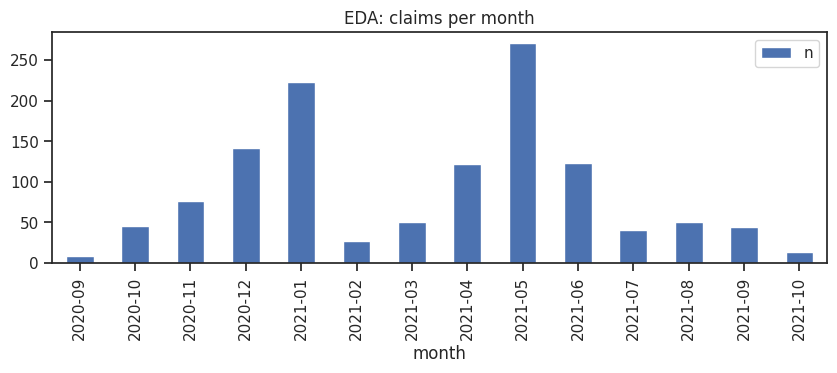

In [4]:
monthly = db.read_sql(
    """
    SELECT strftime('%Y-%m', posted_date) AS month, COUNT(*) AS n
    FROM claims
    WHERE posted_date IS NOT NULL
    GROUP BY month ORDER BY month
    """
)
monthly.plot(x='month', y='n', kind='bar', figsize=(10, 3));
plt.title('EDA: claims per month');

## 3. Outcome distribution

What is the headline approval / rejection split? This drives the
category colours in the polished report plots.

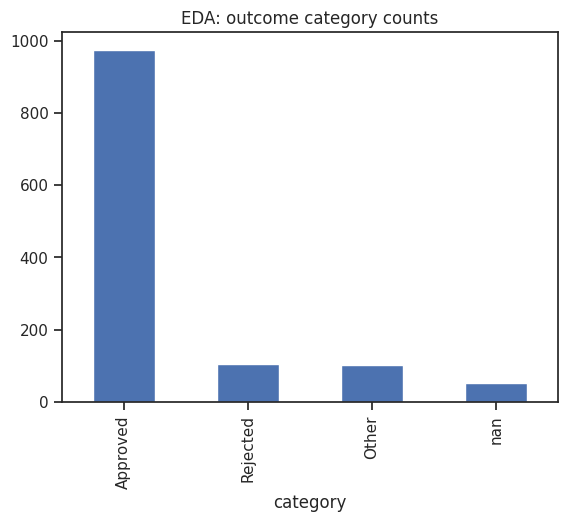

In [5]:
outcome_counts = db.read_sql(
    """
    SELECT o.category, COUNT(*) AS n
    FROM claims c LEFT JOIN outcomes o USING (outcome_code)
    GROUP BY o.category ORDER BY n DESC
    """
)
outcome_counts.plot(x='category', y='n', kind='bar', legend=False);
plt.title('EDA: outcome category counts');

## 4. Days-to-deadline: rough histogram

The polished version of this is `img/q1_claims_vs_deadline_hist.png`.
Here it appears with default styling so that the contrast between
EDA and stakeholder-ready plots is obvious.

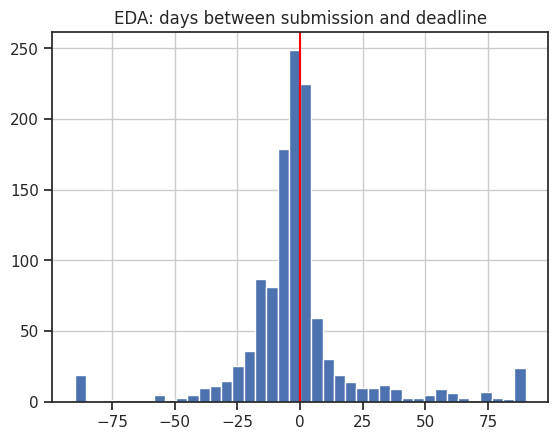

In [6]:
q1 = ECAnalyser(db).q1_days_before_deadline()
q1['days_after_deadline'].clip(-90, 90).hist(bins=40);
plt.axvline(0, color='red');
plt.title('EDA: days between submission and deadline');

## 5. Quick look at module concentration

Confirms that a relatively small number of modules dominate the
claim list, which motivates the top-15 cut-off used in the
stakeholder plot for Q2.

37 modules have >=10 claims


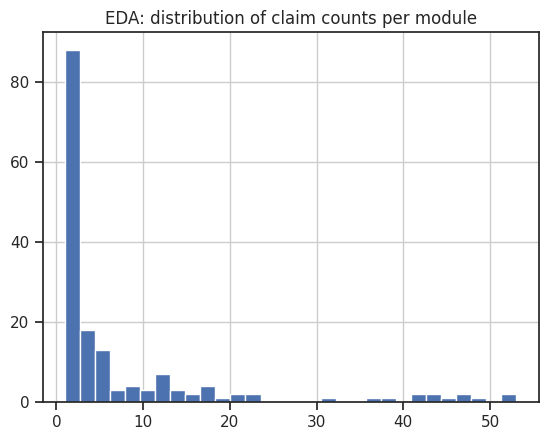

In [7]:
mod_counts = db.read_sql(
    """
    SELECT module_code, COUNT(*) AS n FROM claims
    WHERE module_code IS NOT NULL
    GROUP BY module_code ORDER BY n DESC
    """
)
print(f"{(mod_counts['n'] >= 10).sum()} modules have >=10 claims")
mod_counts['n'].hist(bins=30);
plt.title('EDA: distribution of claim counts per module');

In [8]:
db.close()